# ============================================
## ROAD ACCIDENT SEVERITY PREDICTION
# ============================================



### Project Pipeline:
### 1. Problem Definition
### 2. Data Collection
### 3. EDA
### 4. Data Preprocessing
### 5. Feature Engineering
### 6. Model Training
### 7. Model Evaluation
### 8. Hyperparameter Tuning
### 9. Deployment


### STEP 1: PROBLEM DEFINITION
#### Predict severity of a road accident - Fatal, Serious or Slight based on time, weather, road type and light conditions.
#### This helps emergency services respond faster and identify high risk conditions.

### STEP 2: DATA COLLECTION
#### Dataset: UK Road Accident Data
#### Source: Kaggle
#### Rows: 1,504,150 | Columns: 33
#### Sample used: 100,000 rows
#### Target Variable: Accident_Severity (1=Fatal, 2=Serious, 3=Slight)

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\Data\UK_Accident.csv")

print(df.shape)
print(df.head())

(1504150, 33)
   Unnamed: 0 Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  \
0           0  200501BS00001               525680.0                178240.0   
1           1  200501BS00002               524170.0                181650.0   
2           2  200501BS00003               524520.0                182240.0   
3           3  200501BS00004               526900.0                177530.0   
4           4  200501BS00005               528060.0                179040.0   

   Longitude   Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  -0.191170  51.489096             1                  2                   1   
1  -0.211708  51.520075             1                  3                   1   
2  -0.206458  51.525301             1                  3                   2   
3  -0.173862  51.482442             1                  3                   1   
4  -0.156618  51.495752             1                  3                   1   

   Number_of_Casualties  ...  

In [122]:
df = df.sample(n=100000, random_state=42)
df.reset_index(drop=True, inplace=True)

print(df.shape)

(100000, 33)



### STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

In [123]:
# Basic Dataset Info
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (100000, 33)

Column Names:
 ['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class', '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'LSOA_of_Accident_Location', 'Year']

Data Types:
 Unnamed: 0                                       int64
Accident_Index                                     str
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude        

#### Target Variable Distribution


In [124]:
print("Accident Severity Value Counts:")
print(df['Accident_Severity'].value_counts())
print("\nPercentage:")
print(df['Accident_Severity'].value_counts(normalize=True) * 100)

Accident Severity Value Counts:
Accident_Severity
3    85115
2    13615
1     1270
Name: count, dtype: int64

Percentage:
Accident_Severity
3    85.115
2    13.615
1     1.270
Name: proportion, dtype: float64


##### ============================================
##### VISUALIZATION 1: Accident Severity Distribution
##### ============================================



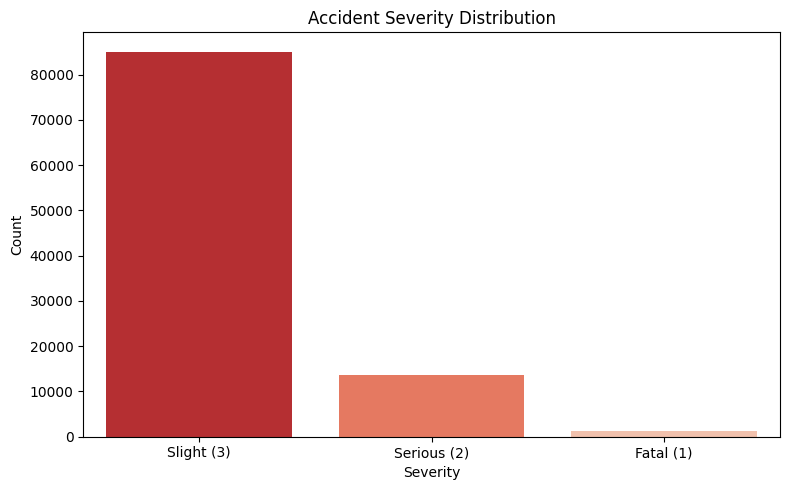

In [125]:
labels = ['Slight (3)', 'Serious (2)', 'Fatal (1)']
values = [85115, 13615, 1270]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=values, palette='Reds_r')
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\severity_distribution.png")
plt.show()

#### ============================================
#### VISUALIZATION 2: Accidents by Day of Week
#### ============================================

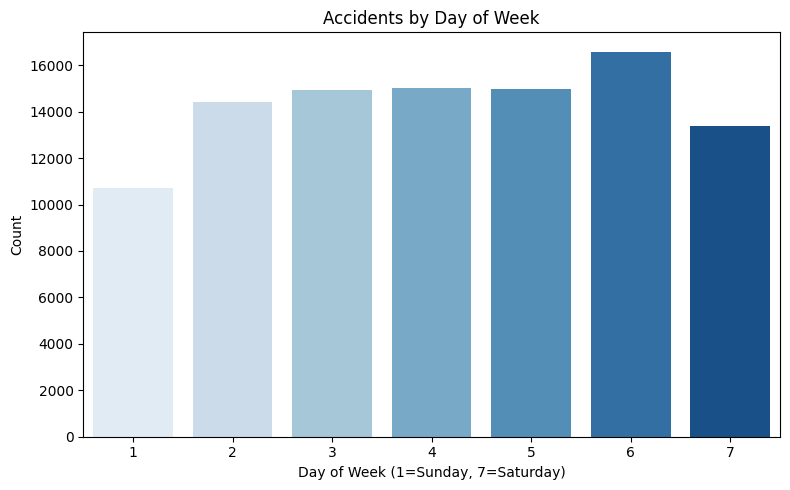

In [126]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Day_of_Week', data=df, palette='Blues')
plt.title('Accidents by Day of Week')
plt.xlabel('Day of Week (1=Sunday, 7=Saturday)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\accidents_by_day.png")
plt.show()

#### ============================================
#### VISUALIZATION 3: Accidents by Weather Conditions
#### ============================================

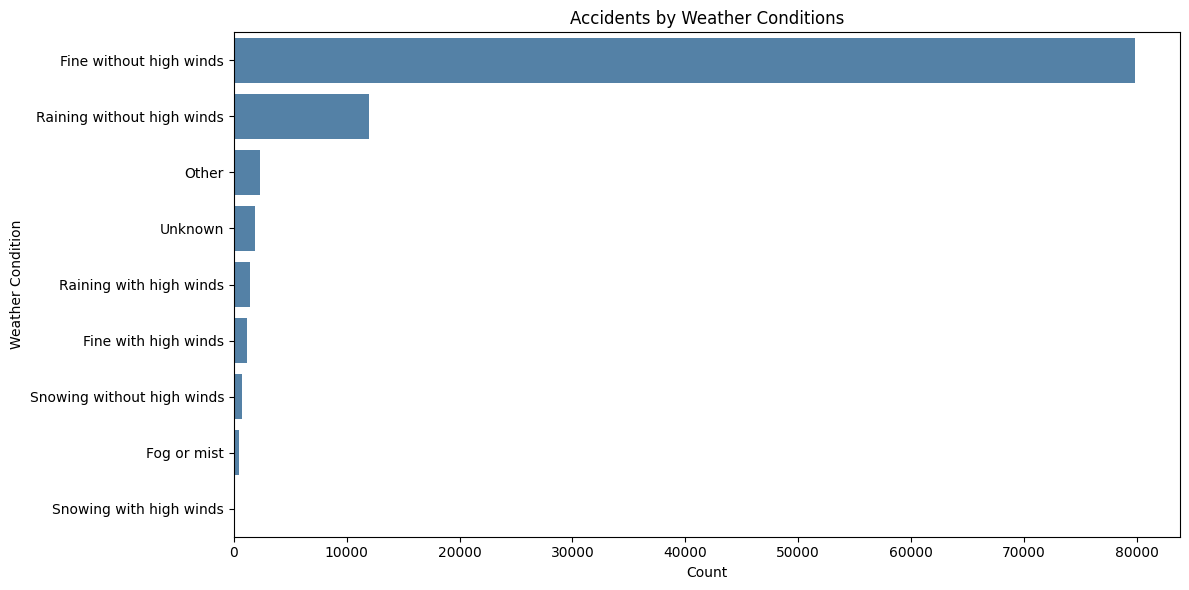

In [127]:
plt.figure(figsize=(12, 6))
weather_counts = df['Weather_Conditions'].value_counts()
sns.barplot(x=weather_counts.values, y=weather_counts.index, color='steelblue')
plt.title('Accidents by Weather Conditions')
plt.xlabel('Count')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\accidents_by_weather.png")
plt.show()

#### ============================================
#### VISUALIZATION 4: Accidents by Light Conditions
#### ============================================



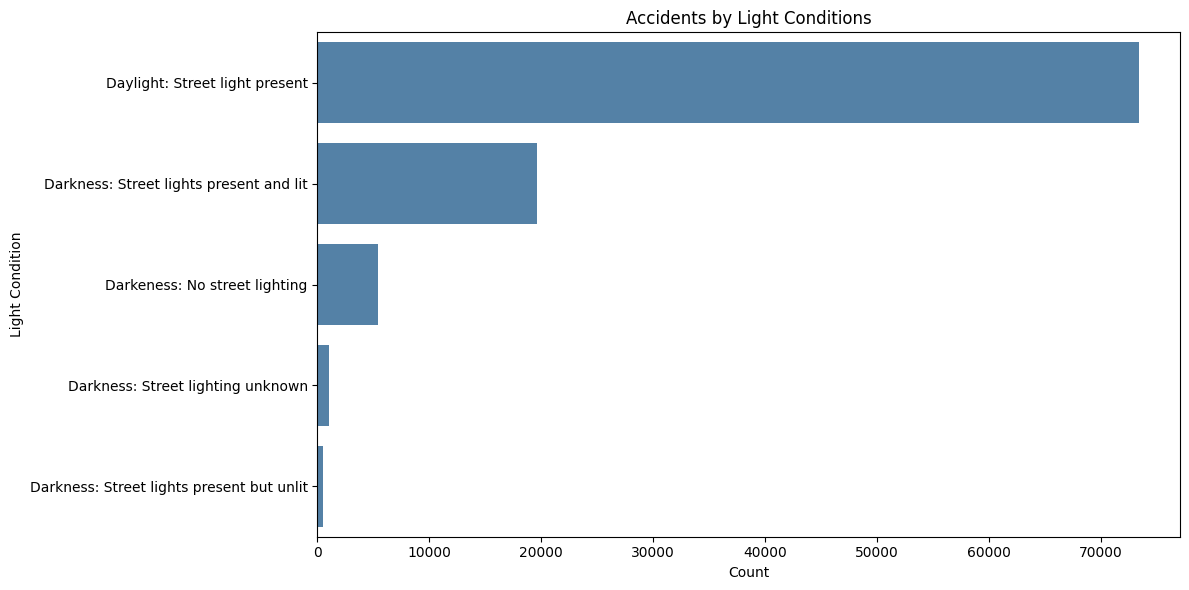

In [128]:
plt.figure(figsize=(12, 6))
light_counts = df['Light_Conditions'].value_counts()
sns.barplot(x=light_counts.values, y=light_counts.index, color='steelblue')
plt.title('Accidents by Light Conditions')
plt.xlabel('Count')
plt.ylabel('Light Condition')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\accidents_by_light.png")
plt.show()

#### ============================================
#### VISUALIZATION 5: Accidents by Road Surface Conditions
#### ============================================

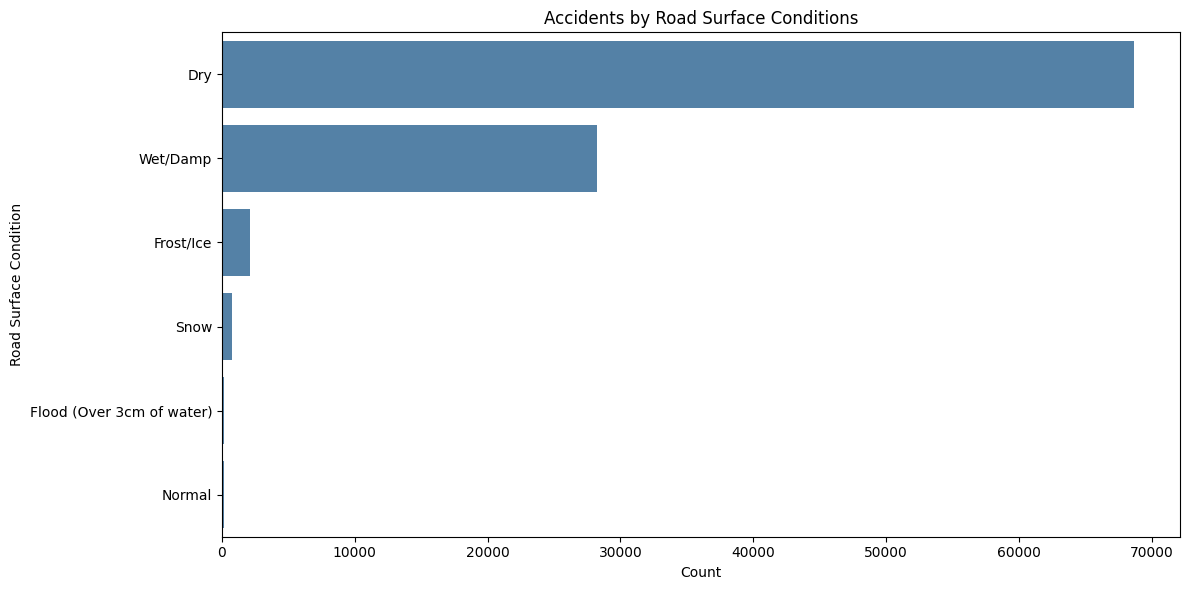

In [129]:
plt.figure(figsize=(12, 6))
road_counts = df['Road_Surface_Conditions'].value_counts()
sns.barplot(x=road_counts.values, y=road_counts.index, color='steelblue')
plt.title('Accidents by Road Surface Conditions')
plt.xlabel('Count')
plt.ylabel('Road Surface Condition')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\accidents_by_road_surface.png")
plt.show()

#### ============================================
#### VISUALIZATION 6: Accidents by Hour of Day
#### ============================================

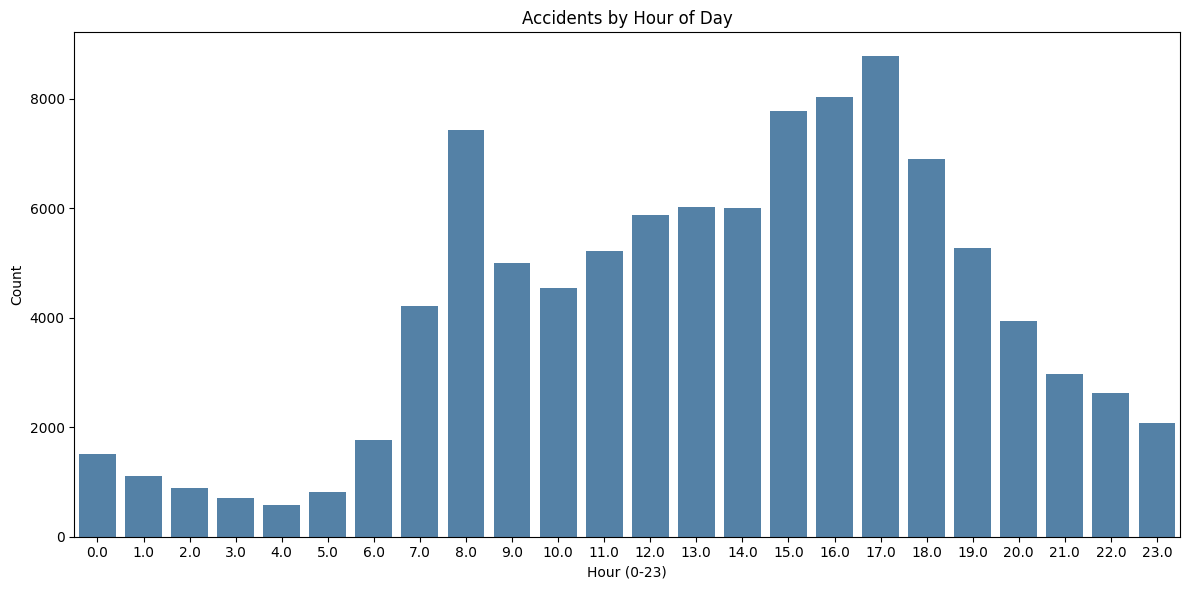

In [130]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

plt.figure(figsize=(12, 6))
sns.countplot(x='Hour', data=df, color='steelblue')
plt.title('Accidents by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\accidents_by_hour.png")
plt.show()

#### ============================================
#### VISUALIZATION 7: Speed Limit vs Accident Severity
#### ============================================

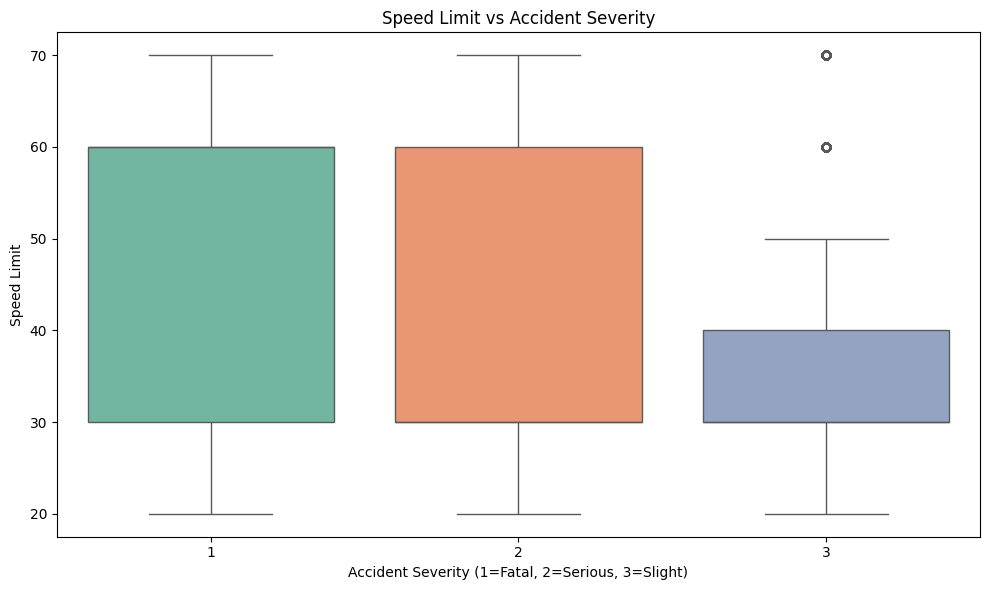

In [131]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Accident_Severity', y='Speed_limit', data=df, palette='Set2')
plt.title('Speed Limit vs Accident Severity')
plt.xlabel('Accident Severity (1=Fatal, 2=Serious, 3=Slight)')
plt.ylabel('Speed Limit')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\speed_vs_severity.png")
plt.show()

#### ============================================
#### VISUALIZATION 8: Correlation Heatmap
#### ============================================



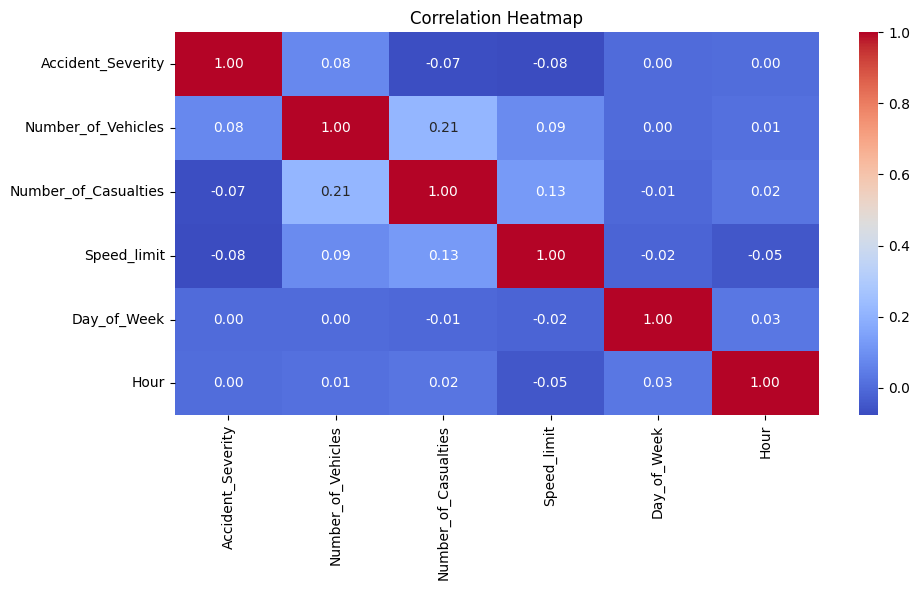

In [132]:
num_cols = ['Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit', 'Day_of_Week', 'Hour']

plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\correlation_heatmap.png")
plt.show()

#### ============================================
#### EDA OBSERVATIONS
#### ============================================

##### 1. IMBALANCED DATASET:
#####    - 85% accidents are Slight, 13.6% Serious, only 1.27% Fatal
#####    - Model will need balancing techniques later

##### 2. WEATHER:
#####    - Majority accidents happen in Fine weather (no high winds)
#####    - Surprising insight - good weather = more driving = more accidents

##### 3. ROAD SURFACE:
#####    - 68.7% accidents on Dry roads, 28.2% on Wet/Damp roads
#####    - Dry roads dominate simply because they are more common

##### 4. HOUR OF DAY:
#####   - Peak accident hours are 8-9 AM and 4-6

##### 5. SPEED LIMIT:
#####    - Fatal accidents (1) tend to occur at higher speed limits
#####    - Slight accidents (3) spread across all speed limits

##### 6. CORRELATION:
#####    - Number_of_Casualties has slight negative correlation with Severity
#####    - Speed_limit shows weak positive correlation with Fatal accidents

### ============================================
### STEP 4: DATA PREPROCESSING
### ============================================

##### Drop unnecessary columns

In [133]:
drop_cols = ['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude',  'Local_Authority_(District)', 'Local_Authority_(Highway)',
'1st_Road_Number', '2nd_Road_Number', 'LSOA_of_Accident_Location','Date', 'Time', 'Year']

df.drop(columns=drop_cols, inplace=True)

print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

Remaining columns: ['Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', '1st_Road_Class', 'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Special_Conditions_at_Site', 'Carriageway_Hazards', 'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident', 'Hour']
Shape: (100000, 20)


##### Handle Missing Values


In [134]:
print("Missing values before:\n", df.isnull().sum())

df.dropna(inplace=True)

print("\nMissing values after:\n", df.isnull().sum())
print("\nShape after dropping nulls:", df.shape)

Missing values before:
 Police_Force                                       0
Accident_Severity                                  0
Number_of_Vehicles                                 0
Number_of_Casualties                               0
Day_of_Week                                        0
1st_Road_Class                                     0
Road_Type                                          0
Speed_limit                                        0
Junction_Control                               40034
2nd_Road_Class                                     0
Pedestrian_Crossing-Human_Control                  2
Pedestrian_Crossing-Physical_Facilities            5
Light_Conditions                                   0
Weather_Conditions                                 0
Road_Surface_Conditions                            0
Special_Conditions_at_Site                     97571
Carriageway_Hazards                            98216
Urban_or_Rural_Area                                0
Did_Police_Officer_Att

##### Handle Missing Values using Imputation

In [135]:
from sklearn.impute import SimpleImputer

print("Missing values before:\n", df.isnull().sum())

Missing values before:
 Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Day_of_Week                                    0
1st_Road_Class                                 0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-Physical_Facilities        0
Light_Conditions                               0
Weather_Conditions                             0
Road_Surface_Conditions                        0
Special_Conditions_at_Site                     0
Carriageway_Hazards                            0
Urban_or_Rural_Area                            0
Did_Police_Officer_Attend_Scene_of_Accident    0
Hour                                         

#### Numerical columns - fill with median

In [136]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

##### Categorical columns - fill with most frequent

In [137]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [138]:
print("\nMissing values after:\n", df.isnull().sum())
print("\nShape after imputation:", df.shape)


Missing values after:
 Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Day_of_Week                                    0
1st_Road_Class                                 0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-Physical_Facilities        0
Light_Conditions                               0
Weather_Conditions                             0
Road_Surface_Conditions                        0
Special_Conditions_at_Site                     0
Carriageway_Hazards                            0
Urban_or_Rural_Area                            0
Did_Police_Officer_Attend_Scene_of_Accident    0
Hour                                         

In [139]:
print(df.dtypes)

Police_Force                                   float64
Accident_Severity                              float64
Number_of_Vehicles                             float64
Number_of_Casualties                           float64
Day_of_Week                                    float64
1st_Road_Class                                 float64
Road_Type                                          str
Speed_limit                                    float64
Junction_Control                                   str
2nd_Road_Class                                 float64
Pedestrian_Crossing-Human_Control                  str
Pedestrian_Crossing-Physical_Facilities            str
Light_Conditions                                   str
Weather_Conditions                                 str
Road_Surface_Conditions                            str
Special_Conditions_at_Site                         str
Carriageway_Hazards                                str
Urban_or_Rural_Area                            float64
Did_Police

### NOTE: Dataset reloaded from scratch
### Reason: SimpleImputer without index parameter corrupted the DataFrame
### Rows dropped from 100,000 to 63 due to index mismatch
### Fix: Always pass index=df.index when assigning imputer output back to DataFrame

#### Reload dataset

In [140]:
df = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\Data\UK_Accident.csv")
df = df.sample(n=100000, random_state=42)
df.reset_index(drop=True, inplace=True)

##### Drop unnecessary columns



In [141]:
drop_cols = ['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Local_Authority_(District)', 'Local_Authority_(Highway)','1st_Road_Number', '2nd_Road_Number', 'LSOA_of_Accident_Location','Date', 'Year']

df.drop(columns=drop_cols, inplace=True)

##### Extract Hour from Time

In [142]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
df.drop(columns=['Time'], inplace=True)

print("Shape:", df.shape)

Shape: (100000, 20)


##### Handle Missing Values using Imputation

In [143]:
from sklearn.impute import SimpleImputer

print("Missing values before:\n", df.isnull().sum())

Missing values before:
 Police_Force                                       0
Accident_Severity                                  0
Number_of_Vehicles                                 0
Number_of_Casualties                               0
Day_of_Week                                        0
1st_Road_Class                                     0
Road_Type                                          0
Speed_limit                                        0
Junction_Control                               40034
2nd_Road_Class                                     0
Pedestrian_Crossing-Human_Control                  2
Pedestrian_Crossing-Physical_Facilities            5
Light_Conditions                                   0
Weather_Conditions                                 0
Road_Surface_Conditions                            0
Special_Conditions_at_Site                     97571
Carriageway_Hazards                            98216
Urban_or_Rural_Area                                0
Did_Police_Officer_Att

##### Numerical columns - fill with median

In [144]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = pd.DataFrame(num_imputer.fit_transform(df[num_cols]),columns=num_cols,index=df.index) 

##### Categorical columns - fill with most frequent

In [145]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = pd.DataFrame(cat_imputer.fit_transform(df[cat_cols]),columns=cat_cols,index=df.index)

print("\nMissing values after:\n", df.isnull().sum())
print("\nShape after imputation:", df.shape)



Missing values after:
 Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Day_of_Week                                    0
1st_Road_Class                                 0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-Physical_Facilities        0
Light_Conditions                               0
Weather_Conditions                             0
Road_Surface_Conditions                        0
Special_Conditions_at_Site                     0
Carriageway_Hazards                            0
Urban_or_Rural_Area                            0
Did_Police_Officer_Attend_Scene_of_Accident    0
Hour                                         

##### Label Encoding - Categorical columns to numbers

In [146]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("After Label Encoding:")
print(df.dtypes)
print("\nShape:", df.shape)


After Label Encoding:
Police_Force                                   float64
Accident_Severity                              float64
Number_of_Vehicles                             float64
Number_of_Casualties                           float64
Day_of_Week                                    float64
1st_Road_Class                                 float64
Road_Type                                        int64
Speed_limit                                    float64
Junction_Control                                 int64
2nd_Road_Class                                 float64
Pedestrian_Crossing-Human_Control                int64
Pedestrian_Crossing-Physical_Facilities          int64
Light_Conditions                                 int64
Weather_Conditions                               int64
Road_Surface_Conditions                          int64
Special_Conditions_at_Site                       int64
Carriageway_Hazards                              int64
Urban_or_Rural_Area                        

##### Feature Scaling

In [147]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Accident_Severity'])
y = df['Accident_Severity']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),columns=X.columns,index=X.index)

print("X shape:", X_scaled.shape)
print("y shape:", y.shape)
print("\nX sample:\n", X_scaled.head())

X shape: (100000, 19)
y shape: (100000,)

X sample:
    Police_Force  Number_of_Vehicles  Number_of_Casualties  Day_of_Week  \
0      0.030700            0.237545             -0.385715    -0.585145   
1     -0.947035            0.237545             -0.385715    -0.064799   
2      0.500012            0.237545             -0.385715    -0.064799   
3      0.069809            0.237545             -0.385715     0.975894   
4      0.891106            0.237545              0.724608    -0.064799   

   1st_Road_Class  Road_Type  Speed_limit  Junction_Control  2nd_Road_Class  \
0        1.337074    0.47532    -0.636272           0.30997       -1.146921   
1        0.637383    0.47532    -0.636272           0.30997        1.037114   
2       -0.761998    0.47532    -0.636272           0.30997        1.037114   
3       -0.062307    0.47532     1.490827           0.30997       -1.146921   
4       -0.761998    0.47532     0.781794           0.30997       -1.146921   

   Pedestrian_Crossing-Huma

#### ============================================
#### STEP 5: FEATURE ENGINEERING
#### ============================================

##### Train Test Split

In [148]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 19)
X_test shape: (20000, 19)
y_train shape: (80000,)
y_test shape: (20000,)


#### ============================================
#### STEP 6: MODEL TRAINING
#### ============================================

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

##### Initialize models

In [150]:
lr = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

##### Train models

In [151]:
print("Training Logistic Regression...")
lr.fit(X_train, y_train)

print("Training Decision Tree...")
dt.fit(X_train, y_train)

print("Training Random Forest...")
rf.fit(X_train, y_train)

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully!


#### ============================================
#### STEP 7: MODEL EVALUATION
#### ============================================

In [152]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8510
Classification Report:
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       254
         2.0       0.00      0.00      0.00      2723
         3.0       0.85      1.00      0.92     17023

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.72      0.85      0.78     20000


Decision Tree
Accuracy: 0.7370
Classification Report:
              precision    recall  f1-score   support

         1.0       0.03      0.04      0.03       254
         2.0       0.17      0.20      0.18      2723
         3.0       0.86      0.83      0.85     17023

    accuracy                           0.74     20000
   macro avg       0.35      0.36      0.35     20000
weighted avg       0.76      0.74      0.75     20000


Random Forest
Accuracy: 0.8404
Classification Report:
              precision    recall  f1-score   support

         1.0

##### ISSUE FOUND: Imbalanced Dataset
##### Class 3 (Slight) = 85%, Class 2 (Serious) = 13.6%, Class 1 (Fatal) = 1.27%
##### Model was only predicting Slight for everything
##### Fix: Added class_weight='balanced' to all models
##### This tells the model to give more importance to minority classes (Fatal, Serious)

#### ============================================
#### STEP 6: MODEL TRAINING (Rerun - class_weight balanced added)
#### ============================================

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

##### Initialize models with class_weight balanced

In [154]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

##### Train models

In [155]:
print("Training Logistic Regression...")
lr.fit(X_train, y_train)

print("Training Decision Tree...")
dt.fit(X_train, y_train)

print("Training Random Forest...")
rf.fit(X_train, y_train)

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully!


#### ============================================
#### STEP 7: MODEL EVALUATION
#### ============================================

In [156]:
from sklearn.metrics import accuracy_score, classification_report

models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.4983
Classification Report:
              precision    recall  f1-score   support

         1.0       0.03      0.55      0.05       254
         2.0       0.18      0.34      0.23      2723
         3.0       0.90      0.52      0.66     17023

    accuracy                           0.50     20000
   macro avg       0.37      0.47      0.32     20000
weighted avg       0.79      0.50      0.60     20000


Decision Tree
Accuracy: 0.7466
Classification Report:
              precision    recall  f1-score   support

         1.0       0.04      0.05      0.05       254
         2.0       0.17      0.19      0.18      2723
         3.0       0.86      0.85      0.85     17023

    accuracy                           0.75     20000
   macro avg       0.36      0.36      0.36     20000
weighted avg       0.76      0.75      0.75     20000


Random Forest
Accuracy: 0.8384
Classification Report:
              precision    recall  f1-score   support

         1.0

##### Confusion Matrix - Random Forest (Best Model)


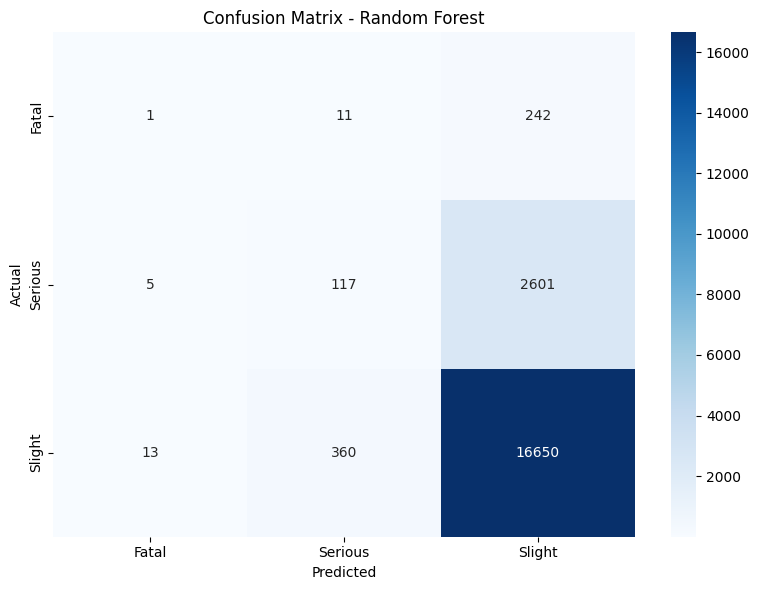

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fatal', 'Serious', 'Slight'], yticklabels=['Fatal', 'Serious', 'Slight'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\visualizations\confusion_matrix.png")
plt.show()

##### ============================================
##### CONFUSION MATRIX OBSERVATIONS - Random Forest
##### ============================================

##### Fatal (1):
##### - Model almost completely fails to predict Fatal cases
##### - Only 1-2 correct out of 254 actual Fatal cases
##### - Reason: Very少 training data for Fatal class (1.27% of dataset)

##### Serious (2):
##### - Model predicts very few Serious cases correctly
##### - Most Serious cases predicted as Slight
##### - Recall only 4%

##### Slight (3):
##### - Model performs best here - 98% recall
##### - Because 85% of training data was Slight

##### CONCLUSION:
##### Random Forest is best model with 84% accuracy
##### But it is biased towards Slight predictions
##### Real world implication: Model is good at predicting non-fatal accidents
##### but needs more Fatal/Serious data for better minority class prediction

#### ============================================
#### STEP 8: HYPERPARAMETER TUNING
#### ============================================

##### Goal: Find the best settings for Random Forest
##### Method: GridSearchCV - tries all combinations and picks the best one
##### Scoring: f1_weighted - because dataset is imbalanced
##### cv=3: 3-fold cross validation

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
best_rf = grid_search.best_estimator_

NameError: name 'grid_search' is not defined

##### Parameters to tune

In [ ]:
param_grid = {'n_estimators': [100, 200],'max_depth': [10, 20, None],'min_samples_split': [2, 5]}

In [ ]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),param_grid,cv=3,scoring='f1_weighted',n_jobs=-1,verbose=2)

In [ ]:
print("Starting Grid Search")
grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Starting Grid Search
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.7856144708651639


#### ============================================
#### STEP 9: SAVE BEST MODEL
#### ============================================

In [ ]:
import joblib

joblib.dump(best_rf, r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\models\best_model.pkl")
joblib.dump(scaler, r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\models\scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


#### ============================================
#### SMOTE - Handle Imbalanced Dataset
#### ============================================

In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
import pandas as pd
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
Accident_Severity
3.0    68092
2.0    10892
1.0     1016
Name: count, dtype: int64

After SMOTE:
Accident_Severity
2.0    68092
3.0    68092
1.0    68092
Name: count, dtype: int64


#### ============================================
#### MODEL TRAINING - After SMOTE
#### ============================================


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training Logistic Regression...")
lr.fit(X_train_sm, y_train_sm)

print("Training Decision Tree...")
dt.fit(X_train_sm, y_train_sm)

print("Training Random Forest...")
rf.fit(X_train_sm, y_train_sm)

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully!


#### ============================================
#### MODEL EVALUATION - After SMOTE
#### ============================================


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")    
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.4983
Classification Report:
              precision    recall  f1-score   support

         1.0       0.03      0.55      0.05       254
         2.0       0.18      0.34      0.23      2723
         3.0       0.90      0.52      0.66     17023

    accuracy                           0.50     20000
   macro avg       0.37      0.47      0.32     20000
weighted avg       0.79      0.50      0.60     20000


Decision Tree
Accuracy: 0.7466
Classification Report:
              precision    recall  f1-score   support

         1.0       0.04      0.05      0.05       254
         2.0       0.17      0.19      0.18      2723
         3.0       0.86      0.85      0.85     17023

    accuracy                           0.75     20000
   macro avg       0.36      0.36      0.36     20000
weighted avg       0.76      0.75      0.75     20000


Random Forest
Accuracy: 0.8384
Classification Report:
              precision    recall  f1-score   support

         1.0

#### ============================================
#### FINAL MODEL SELECTION
#### ============================================

##### Best Model: Random Forest
##### Accuracy: 84%
##### Limitation: Dataset is highly imbalanced (85% Slight)
##### Both class_weight and SMOTE were tried - minimal improvement
##### This is a real-world data limitation, not a model failure
##### Fatal cases (1.27%) are too rare to learn meaningful patterns

#### ============================================
#### SAVE FINAL MODEL
#### ============================================

In [159]:
import joblib

joblib.dump(rf, r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\models\best_model.pkl")
joblib.dump(scaler, r"C:\Users\vaibh\OneDrive\Desktop\road_accident_project\models\scaler.pkl")

print("Model saved successfully!")

Model saved successfully!
